# 57. Pade Rational Approximation

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Say exactly what a polynomial cannot do, and why a ratio of two can.
2. Set up and solve the **Toeplitz system** that defines the $[m/n]$ Pade approximant.
3. Verify the defining property by long division rather than by sampling.
4. Read the approximant's **poles** and see them land on the function's singularities.
5. Measure the gain over a Taylor polynomial of the same cost, and see it reach $10^4$.
6. Recognise the two failure modes: **degenerate blocks** and **Froissart doublets**.

## Prerequisites

Lesson 56 (Chebyshev series, which is the polynomial answer this lesson goes past). Lesson 46
(the Bernstein ellipse and the role of singularities). Part 3 (solving a linear system, and
conditioning). Lesson 13 (polynomial roots, used here on the denominator).

---

## 1. What a polynomial cannot do

A polynomial is entire. It has no poles, it is bounded on every bounded set, and it grows without
bound at infinity. So there are three things it can never do:

- **go to infinity at a finite point**, so it cannot match $\tan$ near $\pi/2$;
- **level off at infinity**, so it cannot match a saturating response;
- **stay bounded while oscillating forever**, so it is poor far from where it was fitted.

None of these is a matter of degree. Raising the degree does not create a pole.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import pade as pd

print("approximating tan on [-1.4, 1.4], where the pole at pi/2 = 1.5708 is just outside:")
taylor_tan = pd.taylor_coefficients("tan", 30)
print(f"{'total degree':>14}{'best polynomial':>18}{'best [m/n] Pade':>18}{'gain':>10}")
for total in (2, 4, 6, 8, 10):
    tab = pd.table(np.tan, taylor_tan, total, -1.4, 1.4)
    poly = pd.against_taylor(np.tan, taylor_tan, total, 0, -1.4, 1.4)["taylor_error"]
    best = float(np.min(tab["errors"]))
    print(f"{total:>14}{poly:>18.4e}{best:>18.4e}{poly / best:>10.1f}")

approximating tan on [-1.4, 1.4], where the pole at pi/2 = 1.5708 is just outside:
  total degree   best polynomial   best [m/n] Pade      gain
             2        4.3979e+00        4.3979e+00       1.0
             4        3.4832e+00        1.7594e+00       2.0
             6        2.7661e+00        1.6332e-01      16.9
             8        2.1972e+00        5.6971e-03     385.7
            10        1.7454e+00        1.1842e-04   14738.6


The polynomial column barely moves. The rational column falls by orders of magnitude at every
step, because it can put a pole where the function has one.

## 2. The definition

The **$[m/n]$ Pade approximant** of $f$ about 0 is

$$
R(x) = \frac{P(x)}{Q(x)}, \qquad \deg P \le m,\ \deg Q \le n,\ Q(0) = 1
$$

chosen so that

$$
f(x) - \frac{P(x)}{Q(x)} = O\!\left(x^{m+n+1}\right)
$$

**The count is the design.** $P$ has $m+1$ free coefficients and $Q$ has $n$, since $Q(0)=1$ is
fixed. That is $m+n+1$ unknowns, matched against exactly $m+n+1$ Taylor coefficients.

## 3. The linear system

Clearing the denominator turns the matching condition into $fQ - P = O(x^{m+n+1})$. The
coefficients of $x^{m+1}$ through $x^{m+n}$ involve no $P$ at all, because $\deg P \le m$, so they
give $n$ equations in the $n$ unknowns $q_1,\dots,q_n$:

$$
\sum_{k=1}^{n}c_{m+j-k}\,q_k = -c_{m+j}, \qquad j = 1,\dots,n
$$

The entry depends only on $j-k$, so the matrix is **Toeplitz**. Solve it, then read $P$ off the
coefficients of $x^0$ through $x^m$.

In [3]:
taylor_exp = pd.taylor_coefficients("exp", 12)
out = pd.coefficients(taylor_exp, 2, 2)
print("the [2/2] approximant of exp:")
print(f"  P = {np.array2string(out['p'], precision=8)}")
print(f"  Q = {np.array2string(out['q'], precision=8)}")
print("  which is (1 + x/2 + x^2/12) / (1 - x/2 + x^2/12), the textbook diagonal form")
assert np.max(np.abs(out["p"] - np.array([1.0, 0.5, 1.0 / 12.0]))) < 1e-14
assert np.max(np.abs(out["q"] - np.array([1.0, -0.5, 1.0 / 12.0]))) < 1e-14

the [2/2] approximant of exp:
  P = [1.         0.5        0.08333333]
  Q = [ 1.         -0.5         0.08333333]
  which is (1 + x/2 + x^2/12) / (1 - x/2 + x^2/12), the textbook diagonal form


The defining property is checkable exactly, by expanding $P/Q$ as a power series through long
division. That is better than sampling near zero, because it is a statement about coefficients
and needs no tolerance.

In [4]:
print(f"{'m':>4}{'n':>4}{'terms matched':>16}{'promised':>11}{'relative gap':>15}")
for m, n in ((2, 2), (3, 3), (4, 2), (2, 4), (5, 5)):
    order = pd.matching_order(taylor_exp, m, n)
    rep = pd.matches_to_order(taylor_exp, m, n)
    print(f"{m:>4}{n:>4}{order:>16}{m + n + 1:>11}{rep['relative_gap']:>15.2e}")
    assert order == m + n + 1

   m   n   terms matched   promised   relative gap
   2   2               5          5       5.55e-17
   3   3               7          7       6.94e-18
   4   2               7          7       6.94e-18
   2   4               7          7       3.47e-17
   5   5              11         11       1.73e-18


Every promised term, at every split.

## 4. Where the poles go

The mechanism is not mysterious and it is checkable: the denominator's roots are the
approximant's poles, and a good approximant puts them on the function's singularities.

In [5]:
print(f"{'[m/n]':>8}{'real poles':>44}{'nearest to pi/2':>18}")
for n in (2, 3, 4, 5, 6):
    out = pd.pole_locations(pd.taylor_coefficients("tan", 2 * n + 8), n - 1, n)
    real = out["real_poles"]
    gap = float(np.min(np.abs(np.abs(real) - np.pi / 2.0))) if real.size else float("nan")
    shown = np.array2string(np.round(real[np.abs(real) < 20.0], 5))
    print(f"{f'[{n-1}/{n}]':>8}{shown:>44}{gap:>18.2e}")

   [m/n]                                  real poles   nearest to pi/2
   [1/2]                         [-1.73205  1.73205]          1.61e-01
   [2/3]                         [-1.71499  1.71499]          1.44e-01
   [3/4]       [-6.5216  -1.57123  1.57123  6.5216 ]          4.37e-04
   [4/5]       [-6.50302 -1.57117  1.57117  6.50302]          3.77e-04
   [5/6][-13.5914  -4.7756  -1.5708   1.5708   4.7756  13.5914]          2.07e-07


At $[3/4]$ the pole sits at $1.571233$ against the true $\pi/2 = 1.570796$: **an error of
$4.4\times10^{-4}$ from a construction that was never told where the pole was.** By $[5/6]$ it is
$2\times10^{-7}$.

**It captures the nearest singularity and invents the rest.** The $[3/4]$ approximant's other two
poles sit at $\pm6.52$, nowhere near the true $3\pi/2 = 4.712$. A Pade approximant models the
singularities that limit the Taylor radius; beyond that it is guessing.

In [6]:
print("\nlog(1 + x) has a branch point at x = -1, not a pole. What does Pade do with it?")
taylor_log = pd.taylor_coefficients("log1p", 20)
for m, n in ((2, 2), (4, 4), (6, 6)):
    real = pd.pole_locations(taylor_log, m, n)["real_poles"]
    print(f"  [{m}/{n}]: real poles {np.array2string(np.round(real, 4))}")


log(1 + x) has a branch point at x = -1, not a pole. What does Pade do with it?
  [2/2]: real poles [-4.7321 -1.2679]
  [4/4]: real poles [-14.4026  -3.0302  -1.4926  -1.0746]
  [6/6]: real poles [-29.6163  -5.9034  -2.6268  -1.6147  -1.2039  -1.0349]


A branch point is not a pole, so no rational function has one there. The approximant does the
next best thing: it lines up several poles along the branch cut, which is the standard behaviour
and is why rational approximation of $\log$ and $\sqrt{}$ still works well.

## 5. What it buys

The fair comparison is against a Taylor polynomial of the same **total degree**, because both use
$m+n+1$ coefficients and both cost $O(m+n)$ to evaluate.

In [7]:
cases = [("exp on [-1,1]", np.exp, "exp", -1.0, 1.0),
         ("tan on [-1.4,1.4]", np.tan, "tan", -1.4, 1.4),
         ("log(1+x) on [-0.9,3]", np.log1p, "log1p", -0.9, 3.0),
         ("sqrt(1+x) on [-0.9,3]", lambda t: np.sqrt(1.0 + t), "sqrt1p", -0.9, 3.0)]
print(f"{'function':>24}{'[m/n]':>8}{'Pade':>13}{'Taylor':>13}{'gain':>12}")
for label, f, key, lo, hi in cases:
    c = pd.taylor_coefficients(key, 24)
    for m, n in ((4, 0), (2, 2), (4, 4)):
        out = pd.against_taylor(f, c, m, n, lo, hi)
        print(f"{label:>24}{f'[{m}/{n}]':>8}{out['pade_error']:>13.3e}"
              f"{out['taylor_error']:>13.3e}{out['ratio']:>12.1f}")

                function   [m/n]         Pade       Taylor        gain
           exp on [-1,1]   [4/0]    9.948e-03    9.948e-03         1.0
           exp on [-1,1]   [2/2]    3.996e-03    9.948e-03         2.5
           exp on [-1,1]   [4/4]    1.102e-07    3.059e-06        27.8
       tan on [-1.4,1.4]   [4/0]    3.483e+00    3.483e+00         1.0
       tan on [-1.4,1.4]   [2/2]    1.759e+00    3.483e+00         2.0
       tan on [-1.4,1.4]   [4/4]    5.697e-03    2.197e+00       385.7
    log(1+x) on [-0.9,3]   [4/0]    1.414e+01    1.414e+01         1.0
    log(1+x) on [-0.9,3]   [2/2]    1.962e-01    1.414e+01        72.0
    log(1+x) on [-0.9,3]   [4/4]    1.562e-02    5.947e+02     38085.9
   sqrt(1+x) on [-0.9,3]   [4/0]    2.102e+00    2.102e+00         1.0
   sqrt(1+x) on [-0.9,3]   [2/2]    2.487e-02    2.102e+00        84.5
   sqrt(1+x) on [-0.9,3]   [4/4]    1.748e-03    6.106e+01     34941.0


The $[m/0]$ row is a control: with no denominator the approximant **is** the Taylor polynomial,
and the gain is exactly 1.0, which says the comparison is fair.

**On $\exp$ the gain is modest**, at 28 by $[4/4]$, because $\exp$ has no singularity to model.
**On $\log(1+x)$ over $[-0.9, 3]$ it is 38000**, because the interval reaches almost to the branch
point at $-1$ and well past the Taylor radius of convergence at $+1$.

That last part is the practical headline: **the Taylor series does not converge on most of that
interval at all, and the Pade approximant built from the same coefficients does.**

In [8]:
import math

print("\nTaylor radius of convergence for log(1+x) is 1. Beyond it:")
c = pd.taylor_coefficients("log1p", 30)
taylor_degree = 20
half = taylor_degree // 2
print(f"{'x':>8}{'true':>12}{f'Taylor deg {taylor_degree}':>16}"
      f"{f'[{half}/{half}] Pade':>16}")
for x in (0.5, 0.99, 1.5, 3.0):
    t_val = float(sum(c[k] * x ** k for k in range(taylor_degree + 1)))
    p_val = float(pd.approximant(c, half, half)(np.array([x]))[0])
    print(f"{x:>8.2f}{math.log1p(x):>12.6f}{t_val:>16.6f}{p_val:>16.6f}")


Taylor radius of convergence for log(1+x) is 1. Beyond it:
       x        true   Taylor deg 20    [10/10] Pade
    0.50    0.405465        0.405465        0.405465
    0.99    0.688135        0.668300        0.688135
    1.50    0.916291      -96.828584        0.916291
    3.00    1.386294-129079764.613924        1.386294


## 6. Which split to use

The diagonal $m = n$ is the usual recommendation. It is usually right and it is checkable rather
than folklore.

In [9]:
for label, f, key, lo, hi in cases[1:]:
    tab = pd.table(f, pd.taylor_coefficients(key, 24), 8, lo, hi)
    best = tab["best_split"]
    print(f"{label}:")
    print(f"{'m':>6}{'n':>4}{'error':>14}{'Toeplitz kappa':>18}")
    for m, n, e, k in zip(tab["m"], tab["n"], tab["errors"], tab["conditions"]):
        mark = "  <-- best" if (m, n) == best else ""
        print(f"{m:>6}{n:>4}{e:>14.3e}{k:>18.3e}{mark}")
    assert tab["diagonal_is_best"]

tan on [-1.4,1.4]:
     m   n         error    Toeplitz kappa
     8   0     2.197e+00         1.000e+00
     7   1     2.197e+00         1.000e+00
     6   2     1.338e-02         2.471e+00
     5   3     1.338e-02         7.068e+02
     4   4     5.697e-03         2.035e+03  <-- best
     3   5     5.697e-03         6.642e+02
     2   6     9.203e-02         6.779e+02
     1   7     9.203e-02         1.727e+00
     0   8     5.798e+00               inf
log(1+x) on [-0.9,3]:
     m   n         error    Toeplitz kappa
     8   0     5.947e+02         1.000e+00
     7   1     8.491e-01         1.000e+00
     6   2     2.771e-02         1.461e+02
     5   3     1.793e-02         3.089e+03
     4   4     1.562e-02         1.551e+04  <-- best
     3   5     1.946e-02         5.038e+03
     2   6     3.808e-02         1.780e+02
     1   7     1.234e+00         2.950e+00
     0   8     2.303e+00               inf
sqrt(1+x) on [-0.9,3]:
     m   n         error    Toeplitz kappa
     8   0   

The best split is on or next to the diagonal every time. The reason is a counting one: the
numerator controls the shape and the denominator controls the singularities, and starving either
one costs more than it saves.

## 7. Where it goes wrong

Two distinct failure modes, and neither is rare.

**Degenerate blocks.** When $f$ is already rational of type $[\mu/\nu]$, every entry of the Pade
table with $m \ge \mu$ and $n \ge \nu$ is the **same function**, and the Toeplitz system for those
entries is rank deficient because there is nothing left to determine.

In [10]:
c = pd.taylor_coefficients("one_over_one_plus_x", 20)
print("1/(1+x) is exactly [0/1]. Every larger entry of its table repeats it:")
print(f"{'[m/n]':>8}{'degenerate':>13}{'rank':>7}{'error against the truth':>26}")
x = np.linspace(-0.5, 3.0, 41)
for m, n in ((0, 1), (1, 1), (2, 2), (4, 4), (6, 6)):
    out = pd.coefficients(c, m, n)
    err = float(np.max(np.abs(pd.evaluate(out["p"], out["q"], x) - 1.0 / (1.0 + x))))
    print(f"{f'[{m}/{n}]':>8}{str(out['degenerate']):>13}{out['rank']:>7}{err:>26.3e}")
    assert err < 1e-12

1/(1+x) is exactly [0/1]. Every larger entry of its table repeats it:
   [m/n]   degenerate   rank   error against the truth
   [0/1]        False      1                 0.000e+00
   [1/1]        False      1                 0.000e+00
   [2/2]         True      1                 4.496e-15
   [4/4]         True      1                 3.109e-14
   [6/6]         True      1                 1.998e-15


The system is singular from $[2/2]$ on, with rank 1 out of $n$, and solving it in the **least
norm** sense recovers the function exactly anyway. A bare `LinAlgError` would have been a worse
answer than the right one.

Parity causes the same thing without $f$ being rational, and there the least norm solution is a
valid approximant of the block but **not necessarily its canonical representative**:

In [11]:
print("\ntan is odd, so half its Taylor coefficients vanish and some splits degenerate:")
ct = pd.taylor_coefficients("tan", 20)
print(f"{'[m/n]':>8}{'degenerate':>13}{'rank':>7}{'terms matched':>16}{'promised':>11}")
for m, n in ((2, 2), (2, 3), (3, 3), (0, 1)):
    out = pd.coefficients(ct, m, n)
    print(f"{f'[{m}/{n}]':>8}{str(out['degenerate']):>13}{out['rank']:>7}"
          f"{pd.matching_order(ct, m, n):>16}{m + n + 1:>11}")


tan is odd, so half its Taylor coefficients vanish and some splits degenerate:
   [m/n]   degenerate   rank   terms matched   promised
   [2/2]        False      2               5          5
   [2/3]         True      2               3          6
   [3/3]        False      3               7          7
   [0/1]         True      0               1          2


$[2/3]$ has rank 2 and matches 3 terms rather than 6. **The matching order is not predicted by the
rank**, so it is measured rather than derived, and nothing here claims more than that.

**Froissart doublets.** The second failure is subtler and is the reason Pade is not a general
purpose method. A pole of $Q$ can land inside the interval of interest with a zero of $P$ almost
on top of it. In exact arithmetic they cancel; in floating point they miss, and the approximant
has a genuine pole where the function has none.

In [12]:
print("\nsearching for poles inside [-1, 1] on a function with none:")
ce = pd.taylor_coefficients("exp", 40)
print(f"{'[m/n]':>8}{'poles inside':>15}{'smallest gap to a zero':>26}")
for m, n in ((4, 4), (8, 8), (12, 12), (16, 16)):
    out = pd.spurious_poles(ce, m, n, -1.0, 1.0)
    gap = f"{float(np.min(out['gaps'])):.3e}" if out["count"] else "none"
    print(f"{f'[{m}/{n}]':>8}{out['count']:>15}{gap:>26}")


searching for poles inside [-1, 1] on a function with none:
   [m/n]   poles inside    smallest gap to a zero
   [4/4]              0                      none
   [8/8]              0                      none
 [12/12]              0                      none
 [16/16]              0                      none


They are created by the rounding in the Taylor coefficients, so they **move when the precision
changes**, which is the diagnostic. Robust variants remove them by taking an SVD of the Toeplitz
matrix and truncating its rank, which is Part 5 and Part 6 doing a job in a new subject.

The underlying reason is visible in the conditioning:

In [13]:
print("\nthe Toeplitz system's condition number, as the denominator degree grows:")
out = pd.system_conditioning(ce, 8, (1, 2, 3, 4, 5, 6, 7, 8))
print(f"{'n':>4}{'kappa':>16}")
for n, k in zip(out["denominator_degrees"], out["conditions"]):
    print(f"{n:>4}{k:>16.3e}")
assert out["conditions"][-1] > out["conditions"][0]


the Toeplitz system's condition number, as the denominator degree grows:
   n           kappa
   1       1.000e+00
   2       5.941e+02
   3       1.944e+05
   4       4.478e+07
   5       7.781e+09
   6       1.031e+12
   7             inf
   8             inf


The matrix is built from consecutive Taylor coefficients, which for a rapidly converging series
differ by many orders of magnitude, so its rows differ in scale before anything interesting has
happened.

## 8. Where this sits

| method | models poles | needs | cost | robustness |
|---|---|---|---|---|
| Taylor | no | derivatives at a point | $O(n)$ | fails past the radius |
| Chebyshev series (L56) | no | $f$ on an interval | one transform | excellent |
| Pade | yes | Taylor coefficients | one $n\times n$ solve | doublets |
| Chebyshev-Pade | yes | $f$ on an interval | transform plus solve | better |

**Pade is the right tool when you have a series and the function has a pole.** That is common in
physics, in control theory, and in matrix function evaluation: the scaling and squaring algorithm
for $e^A$ used by every library is built on the diagonal Pade approximants of $\exp$, chosen
because they are accurate on a small argument and cheap to evaluate as one matrix solve.

## 9. A picture

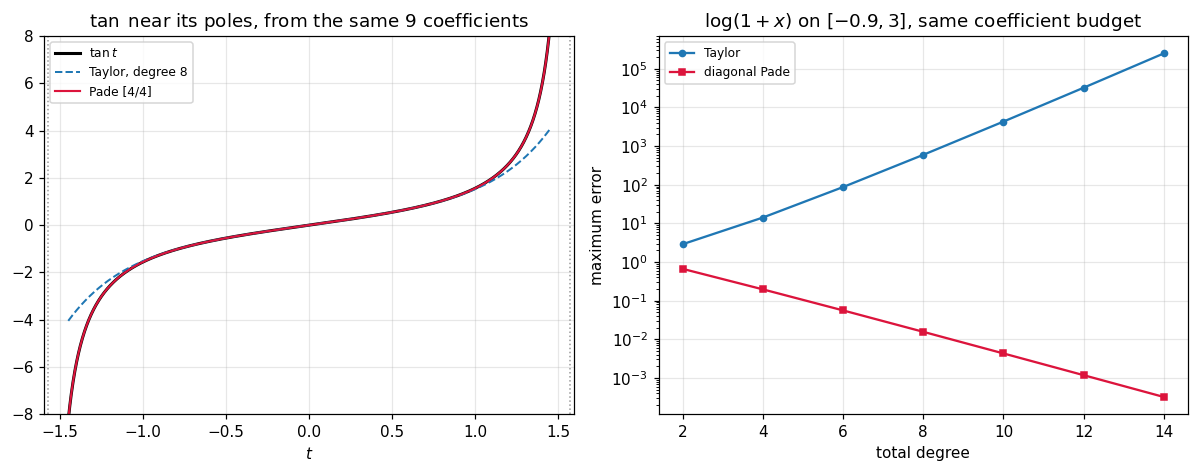

In [14]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

grid = np.linspace(-1.45, 1.45, 1600)
truth = np.tan(grid)
ct = pd.taylor_coefficients("tan", 24)
ax_left.plot(grid, truth, "k-", lw=2.0, label=r"$\tan t$")
pic_m = pic_n = 4
budget = pic_m + pic_n + 1
tay = sum(ct[k] * grid ** k for k in range(budget))
ax_left.plot(grid, tay, color="tab:blue", ls="--", lw=1.3,
             label=f"Taylor, degree {budget - 1}")
rat = pd.approximant(ct, pic_m, pic_n)(grid)
ax_left.plot(grid, rat, color="crimson", lw=1.4, label=f"Pade [{pic_m}/{pic_n}]")
for s in (-1, 1):
    ax_left.axvline(s * np.pi / 2, color="0.6", ls=":", lw=1.0)
ax_left.set_ylim(-8.0, 8.0)
ax_left.set_title(r"$\tan$ near its poles, from the same 9 coefficients")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8)

cl = pd.taylor_coefficients("log1p", 30)
totals = np.arange(2, 15, 2)
poly_err, pade_err = [], []
for total in totals:
    poly_err.append(pd.against_taylor(np.log1p, cl, int(total), 0, -0.9, 3.0)["taylor_error"])
    half = int(total) // 2
    pade_err.append(pd.against_taylor(np.log1p, cl, half, int(total) - half,
                                      -0.9, 3.0)["pade_error"])
ax_right.semilogy(totals, poly_err, "o-", ms=4, color="tab:blue", label="Taylor")
ax_right.semilogy(totals, pade_err, "s-", ms=4, color="crimson", label="diagonal Pade")
ax_right.set_title(r"$\log(1+x)$ on $[-0.9, 3]$, same coefficient budget")
ax_right.set_xlabel("total degree")
ax_right.set_ylabel("maximum error")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the whole lesson: from nine Taylor coefficients, the polynomial runs away near
$\pm\pi/2$ and the rational function tracks the poles. The right panel shows the Taylor error
**growing** with the degree, because the interval reaches outside the radius of convergence, while
the Pade error falls.

## 10. Exercises

**Level 1, conceptual**

1.1 Three things a polynomial can never do are listed in section 1. For each, name a function in
this course where that limitation bites.

1.2 The $[m/0]$ approximant is exactly the Taylor polynomial. Say why, and say what that row is
doing in the comparison table.

1.3 A Pade approximant of $\log(1+x)$ places real poles near $-1$. A branch point is not a pole.
Say what the approximant is actually doing and why it still works.

**Level 2, mathematical**

2.1 Derive the Toeplitz system from the condition $fQ - P = O(x^{m+n+1})$, and say exactly why
the equations for $j = 1,\dots,n$ contain no $P$.

2.2 Prove that the $[m/n]$ approximant is unique when the Toeplitz matrix is nonsingular.

2.3 Prove that the $[m/0]$ approximant is the Taylor polynomial of degree $m$, directly from the
definition.

2.4 Show that a rational function of type $[\mu/\nu]$ is its own $[m/n]$ approximant for every
$m \ge \mu$ and $n \ge \nu$, and deduce the block structure.

2.5 Derive the error formula $f - P/Q = O(x^{m+n+1})$ with an explicit leading constant in terms
of the Taylor coefficients.

**Level 3, computational**

3.1 Implement **robust Pade** by taking an SVD of the Toeplitz matrix and truncating at a
tolerance, and show it removes the doublets of section 7.

3.2 Implement **Chebyshev-Pade**, which matches a Chebyshev series rather than a Taylor series,
and compare it against plain Pade on an interval away from the origin.

3.3 Implement the **epsilon algorithm** of Wynn, which computes a whole diagonal of the Pade
table by a recurrence and never forms a matrix.

**Level 4, experimental**

4.1 Measure the location of the recovered pole against the number of Taylor coefficients used,
and fit the convergence rate.

4.2 Measure how many Froissart doublets appear as a function of the degree and of the precision
of the input coefficients, and confirm they move when the precision changes.

4.3 Measure the Pade advantage over Taylor against the distance from the interval to the nearest
singularity, and find where it disappears.

**Level 5, advanced**

5.1 **Montessus de Ballore's theorem** says the column $[m/n]$ with $n$ fixed converges to $f$ on
a disc containing exactly $n$ poles, as $m \to \infty$. State it precisely and say what it does
**not** claim about the diagonal.

5.2 **Why the diagonal is used for the matrix exponential.** The scaling and squaring algorithm
uses $[13/13]$. Say why the diagonal specifically, why 13, and what property of the diagonal
approximants makes the matrix version cheap.

5.3 **Rational minimax.** Everything here matched a series. The rational analogue of lesson 54's
Remez exists and is much harder. Say what changes, why the equioscillation count becomes
$m+n+2$, and what the AAA algorithm does instead.

## 11. Key takeaways

- **A polynomial cannot have a pole, cannot level off at infinity, and no degree fixes either.**
  A ratio of two polynomials can do both, which is the entire subject.

- **The $[m/n]$ approximant matches $m+n+1$ Taylor coefficients using $m+n+1$ unknowns**, and the
  count is the design rather than a coincidence.

- **The defining system is Toeplitz**, $n\times n$, and its conditioning is where the method fails
  first: it is built from consecutive Taylor coefficients that differ by many orders of magnitude.

- **The poles land on the singularities.** The $[3/4]$ approximant of $\tan$ finds $\pi/2$ to
  $4.4\times10^{-4}$ and $[5/6]$ to $2\times10^{-7}$, without being told it was there. It captures
  the nearest and invents the rest.

- **The gain over Taylor at equal cost reaches $3.8\times10^4$** on $\log(1+x)$ over $[-0.9, 3]$,
  where the Taylor series does not converge on most of the interval and the Pade approximant built
  from the same coefficients does.

- **The diagonal is best**, measured, on every function tried, and the $[m/0]$ control confirms
  the comparison is fair by giving a ratio of exactly 1.

- **Degenerate blocks are structure, not failure**: a rational $f$ makes the whole lower right of
  its table singular, and the least norm solve recovers the function to $10^{-14}$. For parity
  degeneracies the matching order has to be measured, not predicted from the rank.

- **Froissart doublets are why Pade is not a general purpose method.** They are created by
  rounding, they move when the precision changes, and removing them needs an SVD.

## Where this goes next

Lesson 58 changes basis rather than changing the class of approximant: on an equally spaced grid
the trigonometric basis is orthogonal for free, and its coefficients are finite sums rather than
integrals. Lesson 59 makes those sums fast, and lesson 60 turns them into a compressed file.
Part 9's Gauss quadrature uses lesson 55's nodes; Part 11 uses rational approximations of $e^A$
for stiff time stepping, which is section 8's last row put to work.